In [1]:
import os
import torch
import numpy as np
import json
import trimesh
import matplotlib.pyplot as plt
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.decomposition import FastICA
from tqdm import tqdm
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import FloatSlider, interact, HBox, VBox, Box, IntSlider, Dropdown
from IPython.display import display, HTML
import meshplot as mp
from sklearn.decomposition import PCA
from deep_sdf import data, utils, mesh
import deep_sdf.workspace as ws
import networks.sdf_vae as vae

In [2]:
# Path to experiment directory
experiment_directory = "examples/torus_bump_rotate"

# Load specs for paths
specs_filename = os.path.join(experiment_directory, "specs.json")
specs = json.load(open(specs_filename))

# Path to torus dataset and test split
torus_path = specs["TorusPath"]
test_split_file = specs["TrainSplit"]  

# Fix the path by removing any trailing quotes
if torus_path.endswith("'"):
    torus_path = torus_path.rstrip("'")
    print(f"Fixed torus_path: {torus_path}")
# Load the test split
with open(test_split_file, "r") as f:
    test_split = json.load(f)

print(f"Loaded {len(test_split)} test examples")

Fixed torus_path: /home/jakaria/torus_two_models_data/torus_two/obj_files
Loaded 400 test examples


In [6]:
# Function to sample points from a mesh
def sample_points_from_mesh(mesh_path, n_points=5000):
    try:
        mesh = trimesh.load(mesh_path)
        points, _ = trimesh.sample.sample_surface(mesh, n_points)
        return points.flatten()
    except Exception as e:
        print(f"Error processing {mesh_path}: {e}")
        return None

In [7]:
n_points = 5000  # Number of points to sample from each mesh
point_clouds = []
valid_filenames = []
mesh_objects = {}  # Store mesh objects for later visualization

print("Processing meshes...")
for mesh_name in tqdm(test_split, desc="Processing meshes"):
    mesh_path = os.path.join(torus_path, mesh_name)
    if os.path.exists(mesh_path):
        points = sample_points_from_mesh(mesh_path, n_points)
        if points is not None:
            point_clouds.append(points)
            valid_filenames.append(f"{mesh_name}")
            mesh_objects[mesh_name] = trimesh.load(mesh_path)
    else:
        print(f"Mesh file not found: {mesh_path}")

Processing meshes...


Processing meshes: 100%|██████████| 400/400 [00:08<00:00, 47.53it/s]


In [8]:
# Convert to numpy array
X = np.array(point_clouds)
print(f"Dataset shape: {X.shape}")

Dataset shape: (400, 15000)


In [9]:
# Load all labels from the label.pt file
data_source = specs["DataSource"]
labels_path = os.path.join(data_source, "labels.pt")

if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path)
    #print(f"All labels: {all_labels}")
    # Extract parameters for each filename
    mesh_params = []
    for filename in valid_filenames:
        # Extract base name without extension to match with label dict key
        base_name = os.path.splitext(os.path.basename(filename))[0]
        #print(f"Processing {base_name}")
        params = {}
        if base_name in all_labels:
            #print(f"Found label for {base_name}")
            label = all_labels[base_name]
            params["angle"] = (label[0].item())  # angle info at index 0
            params["scale"] = (label[1].item())  # scale info at index 1
        else:
            print(f"Warning: No label found for {base_name}")
            params["angle"] = 0
            params["scale"] = 0
        
        
        mesh_params.append(params)

Loading labels from /home/jakaria/torus_two_models_data/torus_two/sdf_data/SdfSamples/obj_files/labels.pt


In [45]:
print(mesh_params)

[{'angle': -0.9599198396793587, 'scale': 0.7272727272727275}, {'angle': -0.7114228456913828, 'scale': 0.8787878787878793}, {'angle': 0.847695390781563, 'scale': 0.7676767676767677}, {'angle': -0.7274549098196392, 'scale': 0.37373737373737415}, {'angle': -0.8517034068136273, 'scale': 0.2525252525252526}, {'angle': 0.6112224448897794, 'scale': 0.4545454545454546}, {'angle': 0.7074148296593186, 'scale': 1.0}, {'angle': 0.3827655310621241, 'scale': 0.6464646464646466}, {'angle': 0.5150300601202404, 'scale': 0.6666666666666674}, {'angle': 0.002004008016031955, 'scale': 0.27272727272727293}, {'angle': -0.3707414829659319, 'scale': 0.2828282828282829}, {'angle': 0.07414829659318634, 'scale': 0.5959595959595965}, {'angle': -0.29859719438877763, 'scale': 0.4141414141414148}, {'angle': 0.5591182364729457, 'scale': 0.3030303030303032}, {'angle': -0.8196392785571143, 'scale': 0.5656565656565662}, {'angle': 0.6072144288577153, 'scale': 0.2828282828282829}, {'angle': -0.7835671342685371, 'scale': 0.

In [10]:
# Create color coding for visualization based on extracted parameters
angle = np.array([p.get("angle", 0) for p in mesh_params])
scale = np.array([p.get("scale", 0) for p in mesh_params])

In [11]:
# Step 2: Apply HLLE for non-linear dimensionality reduction
n_neighbors = min(400, len(X) - 1)  # Ensuring n_neighbors is valid
print("Applying HLLE (this may take a while for large datasets)...")
hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors, n_components=4, method='hessian', eigen_solver='dense')
Z = hlle.fit_transform(X)
print(f"HLLE embedding shape: {Z.shape}")

Applying HLLE (this may take a while for large datasets)...
HLLE embedding shape: (400, 4)


In [12]:
# Step 3: Apply ICA for disentanglement
print("Applying FastICA...")
ica = FastICA(n_components=4, random_state=42)
Y = ica.fit_transform(Z)
print(f"ICA components shape: {Y.shape}")

Applying FastICA...
ICA components shape: (400, 4)


In [13]:
# Save the results
np.save('latent_factors.npy', Y)
np.save('hlle_embedding.npy', Z)
with open('valid_filenames.json', 'w') as f:
    json.dump(valid_filenames, f)

In [14]:
# Create a DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Component 1': Y[:, 0],
    'Component 2': Y[:, 1],
    'Filename': valid_filenames,
    'Angle': angle
})

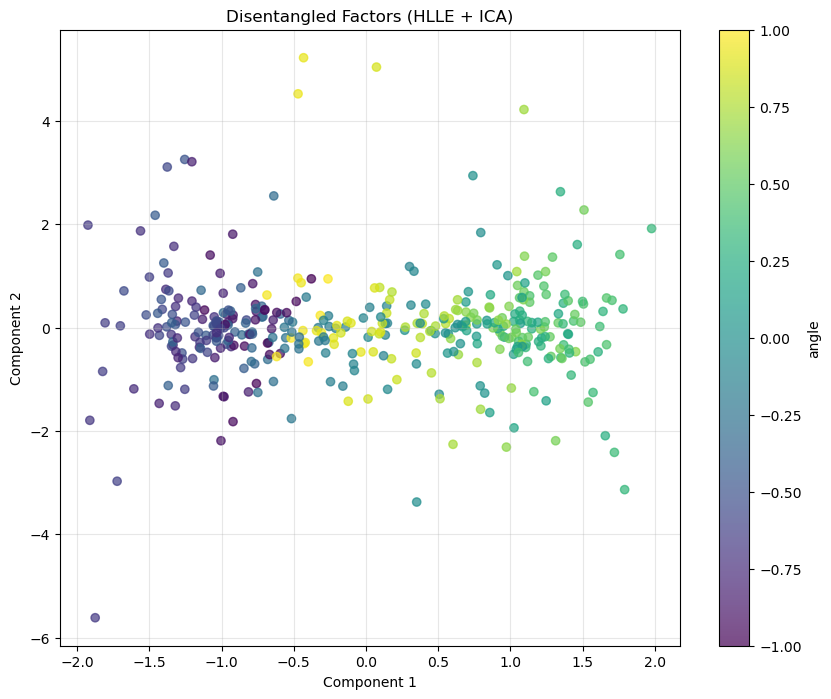

In [15]:
# VISUALIZATION 1: Basic scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(Y[:, 0], Y[:, 1], c=angle, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="angle")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
#plt.xlim(-0.1, 0.1)
#plt.ylim(-0.1, 0.1)
plt.title("Disentangled Factors (HLLE + ICA)")
plt.grid(True, alpha=0.3)
plt.savefig("torus_latent_factors_angle.png", dpi=300)
plt.show()

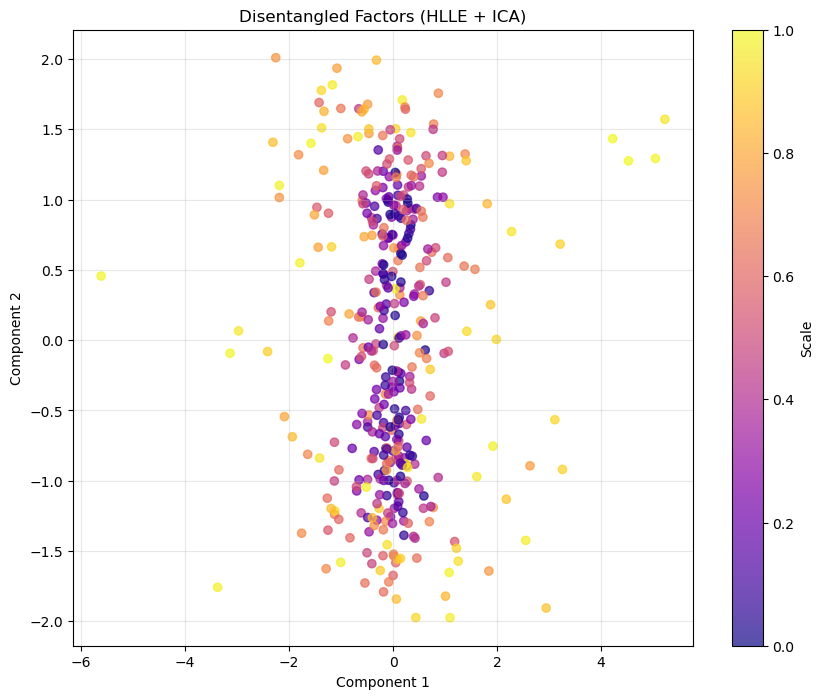

In [16]:
# Alternative coloring by scale
plt.figure(figsize=(10, 8))
if np.any(angle != 0): 
    scatter = plt.scatter(Y[:, 1], Y[:, 3], c=scale, cmap='plasma', alpha=0.7)
    plt.colorbar(scatter, label="Scale")
else:
    scatter = plt.scatter(Y[:, 0], Y[:, 0], alpha=0.7)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
#plt.xlim(-0.2, 0.2)
#plt.ylim(-0.2, 0.2)
plt.title("Disentangled Factors (HLLE + ICA)")
plt.grid(True, alpha=0.3)
plt.savefig("torus_latent_factors_scale.png", dpi=300)
plt.show()

In [17]:
#Correlation analysis
if len(mesh_params) > 0:
    print("\nCorrelation Analysis:")
    for i in range(Y.shape[1]):
        if np.any(angle != 0):
            angle_corr = np.corrcoef(Y[:, i], angle)[0, 1]
            print(f"Component {i+1} correlation with angle: {angle_corr:.4f}")
            scale_corr = np.corrcoef(Y[:, i], scale)[0, 1]
            print(f"Component {i+1} correlation with scale: {scale_corr:.4f}")

# 2. Check if scale is encoded as distance from center in pca

# Calculate distance from center for each point
center = np.mean(Y, axis=0)
distances = np.sqrt(np.sum((Y - center)**2, axis=1))

# Check correlation between distance and scale
dist_scale_corr = np.corrcoef(distances, scale)[0, 1]
print(f"Correlation between distance from center and scale: {dist_scale_corr:.3f}")  


Correlation Analysis:
Component 1 correlation with angle: 0.7141
Component 1 correlation with scale: 0.0562
Component 2 correlation with angle: 0.0608
Component 2 correlation with scale: 0.0309
Component 3 correlation with angle: 0.0381
Component 3 correlation with scale: 0.0387
Component 4 correlation with angle: 0.2810
Component 4 correlation with scale: 0.0234
Correlation between distance from center and scale: 0.707


In [18]:

# Calculate distance from center for each point
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center)**2, axis=1))

# Check correlation between distance and scale
dist_scale_corr = np.corrcoef(distances, scale)[0, 1]
print(f"Correlation between pca distance from center and scale: {dist_scale_corr:.3f}")

NameError: name 'Y_pca' is not defined

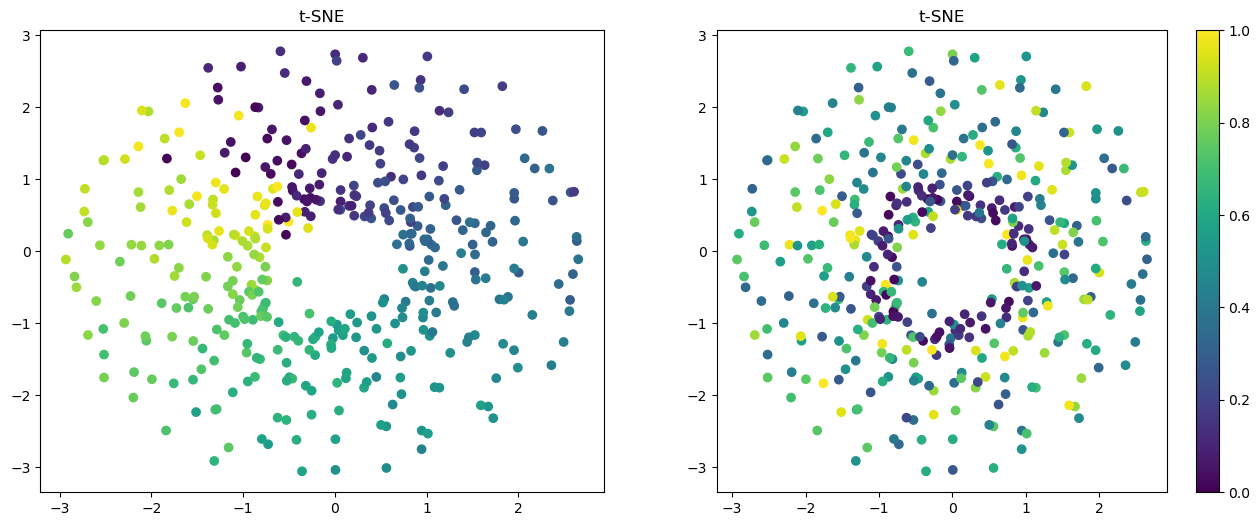

In [ ]:
# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
Y_tsne = tsne.fit_transform(X)

# Plot 
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c=np.array([p["angle"] for p in mesh_params]))
plt.title("t-SNE")

plt.subplot(1, 2, 2)
plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c=np.array([p["scale"] for p in mesh_params]))
plt.title("t-SNE")
plt.colorbar()
plt.show()

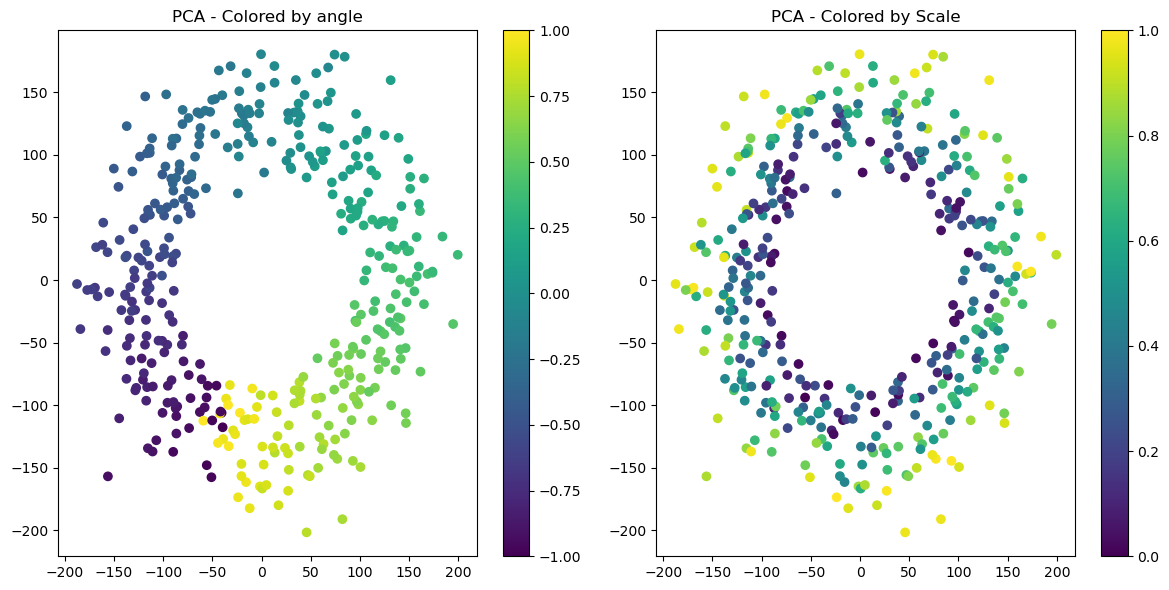

PCA - Scale correlation: dim1=0.061, dim2=-0.020
PCA - angle correlation: dim1=0.720, dim2=-0.269
Correlation between pca distance from center and scale: 0.815
Correlation between t-SNE distance from center and scale: -0.034


In [ ]:
# 1. Try PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Y_pca = pca.fit_transform(X)

# Plot PCA and calculate correlations
angle = np.array([p["angle"] for p in mesh_params])
scale = np.array([p["scale"] for p in mesh_params])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(Y_pca[:, 0], Y_pca[:, 1], c=angle)
plt.title("PCA - Colored by angle")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(Y_pca[:, 0], Y_pca[:, 1], c=scale)
plt.title("PCA - Colored by Scale")
plt.colorbar()
plt.tight_layout()
plt.show()

pca_corr_scale_dim1 = np.corrcoef(Y_pca[:, 0], scale)[0, 1]
pca_corr_scale_dim2 = np.corrcoef(Y_pca[:, 1], scale)[0, 1]
print(f"PCA - Scale correlation: dim1={pca_corr_scale_dim1:.3f}, dim2={pca_corr_scale_dim2:.3f}")

pca_corr_angle_dim1 = np.corrcoef(Y_pca[:, 0], angle)[0, 1]
pca_corr_angle_dim2 = np.corrcoef(Y_pca[:, 1], angle)[0, 1]
print(f"PCA - angle correlation: dim1={pca_corr_angle_dim1:.3f}, dim2={pca_corr_angle_dim2:.3f}")

# 2. Check if scale is encoded as distance from center in pca

# Calculate distance from center for each point
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center)**2, axis=1))

# Check correlation between distance and scale
dist_scale_corr = np.corrcoef(distances, scale)[0, 1]
print(f"Correlation between pca distance from center and scale: {dist_scale_corr:.3f}")

# 2. Check if scale is encoded as distance from center in t-SNE
# For the original t-SNE with perplexity=30
tsne = TSNE(n_components=2, perplexity=30)
Y_tsne = tsne.fit_transform(X)

# Calculate distance from center for each point
center = np.mean(Y_tsne, axis=0)
distances = np.sqrt(np.sum((Y_tsne - center)**2, axis=1))

# Check correlation between distance and scale
dist_scale_corr = np.corrcoef(distances, angle)[0, 1]
print(f"Correlation between t-SNE distance from center and scale: {dist_scale_corr:.3f}")


NMF components shape: (400, 4)


Text(0, 0.5, 'Component 2')

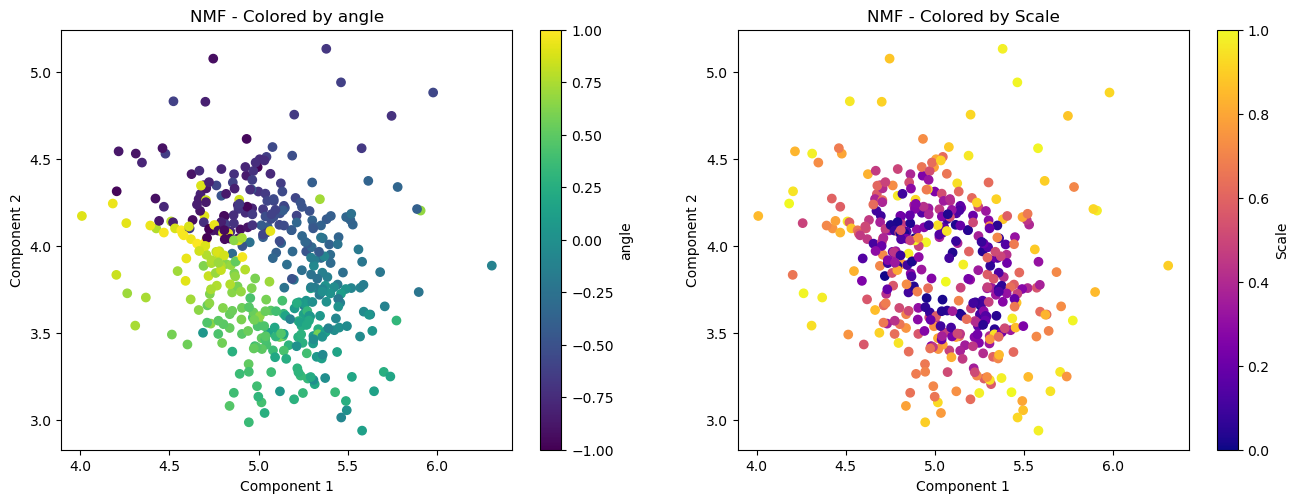

In [ ]:
from sklearn.decomposition import NMF
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Ensure data is non-negative
# NMF requires non-negative values, so we need to transform the data
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min  # Shift data to make all values non-negative
else:
    X_offset = X.copy()

# Step 2: Apply NMF
n_components = 4  # Number of factors to discover
nmf = NMF(n_components=n_components, init='random', random_state=42, max_iter=10000)
Y_nmf = nmf.fit_transform(X_offset)

print(f"NMF components shape: {Y_nmf.shape}")
#print(f"NMF reconstruction error: {nmf.reconstruction_err_}")

# Step 3: Visualize the results
plt.figure(figsize=(16, 12))

# NMF colored by angle
plt.subplot(2, 2, 1)
plt.scatter(Y_nmf[:, 0], Y_nmf[:, 1], c=np.array([p["angle"] for p in mesh_params]), cmap='viridis')
plt.colorbar(label="angle")
plt.title("NMF - Colored by angle")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

# NMF colored by scale
plt.subplot(2, 2, 2)
plt.scatter(Y_nmf[:, 0], Y_nmf[:, 1], c=np.array([p["scale"] for p in mesh_params]), cmap='plasma')
plt.colorbar(label="Scale")
plt.title("NMF - Colored by Scale")
plt.xlabel("Component 1")
plt.ylabel("Component 2")


In [ ]:
# use loop instead of the above step 4 calculation 
# Step 4: Check correlations with known factors
angle_values = np.array([p["angle"] for p in mesh_params])
scale_values = np.array([p["scale"] for p in mesh_params])
# calculate correlations for all the 4 factors
for i in range(Y_nmf.shape[1]):
    nmf_corr_angle = np.corrcoef(Y_nmf[:, i], angle_values)[0, 1]
    nmf_corr_scale = np.corrcoef(Y_nmf[:, i], scale_values)[0, 1]
    print(f"NMF Component {i+1} correlation with angle: {nmf_corr_angle:.3f}")
    print(f"NMF Component {i+1} correlation with scale: {nmf_corr_scale:.3f}")


NMF Component 1 correlation with angle: -0.155
NMF Component 1 correlation with scale: 0.024
NMF Component 2 correlation with angle: -0.532
NMF Component 2 correlation with scale: -0.002
NMF Component 3 correlation with angle: -0.065
NMF Component 3 correlation with scale: -0.056
NMF Component 4 correlation with angle: 0.672
NMF Component 4 correlation with scale: 0.051


Applying FastICA...
ICA components shape: (400, 2)


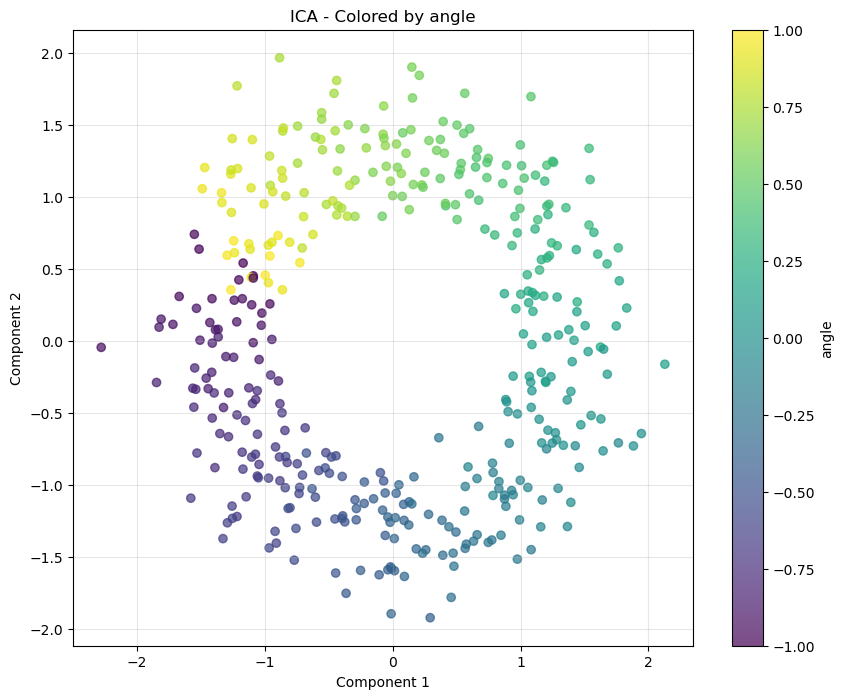

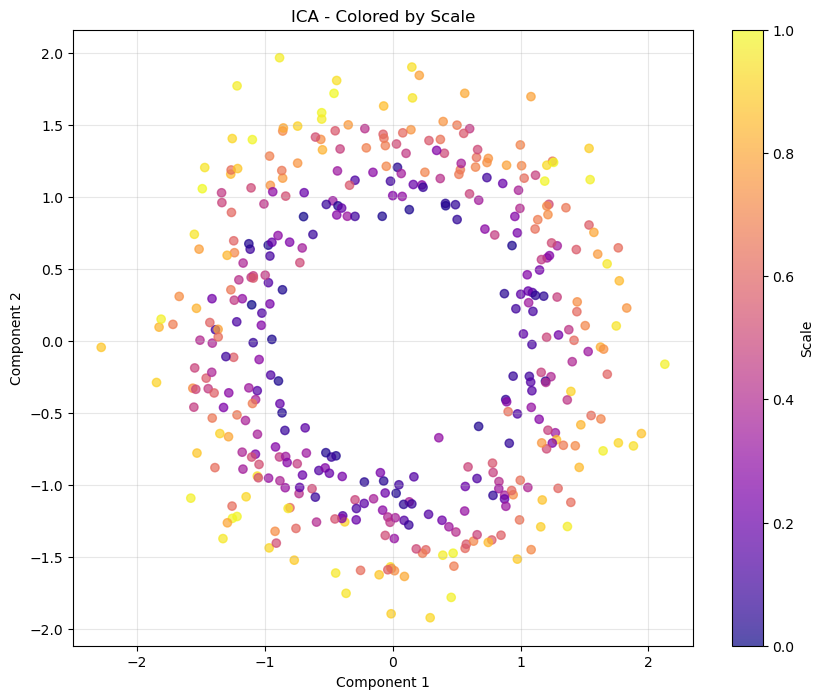

ICA Component 1 correlation with angle: 0.295
ICA Component 2 correlation with angle: 0.710
ICA Component 1 correlation with scale: 0.027
ICA Component 2 correlation with scale: 0.058
Correlation between ICA distance from center and scale: 0.816


In [ ]:
# Applying only ICA
print("Applying FastICA...")
ica = FastICA(n_components=2, random_state=42)
Y_ica = ica.fit_transform(X)
print(f"ICA components shape: {Y_ica.shape}")
# Visualize the results
plt.figure(figsize=(10, 8))
plt.scatter(Y_ica[:, 0], Y_ica[:, 1], c=angle, cmap='viridis', alpha=0.7)
plt.colorbar(label="angle")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("ICA - Colored by angle")
plt.grid(True, alpha=0.3)
plt.show()

# visualize scale
plt.figure(figsize=(10, 8))
if np.any(scale != 0):
    scatter = plt.scatter(Y_ica[:, 0], Y_ica[:, 1], c=scale, cmap='plasma', alpha=0.7)
    plt.colorbar(scatter, label="Scale")
else:
    scatter = plt.scatter(Y_ica[:, 0], Y_ica[:, 1], alpha=0.7)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("ICA - Colored by Scale")
plt.grid(True, alpha=0.3)
plt.show()
# Check correlations with known factors
ica_corr_angle_1 = np.corrcoef(Y_ica[:, 0], angle)[0, 1]
ica_corr_angle_2 = np.corrcoef(Y_ica[:, 1], angle)[0, 1]
ica_corr_scale_1 = np.corrcoef(Y_ica[:, 0], scale)[0, 1]
ica_corr_scale_2 = np.corrcoef(Y_ica[:, 1], scale)[0, 1]

print(f"ICA Component 1 correlation with angle: {ica_corr_angle_1:.3f}")
print(f"ICA Component 2 correlation with angle: {ica_corr_angle_2:.3f}")
print(f"ICA Component 1 correlation with scale: {ica_corr_scale_1:.3f}")
print(f"ICA Component 2 correlation with scale: {ica_corr_scale_2:.3f}")

# check if scale is encoded as distance from center
# Calculate distance from center for each point
center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center)**2, axis=1))
# Check correlation between distance and scale
dist_scale_corr = np.corrcoef(distances, scale)[0, 1]  
print(f"Correlation between ICA distance from center and scale: {dist_scale_corr:.3f}")

